In [1]:
import json 
import os 
import urllib 
from functools import partial 

import tiktoken 
import torch 
from torch.utils.data import Dataset, DataLoader 

from GPT_from_scratch import (
    GPTModel,
    generate,
    text_to_token_ids,
    token_ids_to_text,
    calc_loss_batch,
    calc_loss_loader,
    train_model_simple,
    plot_losses,
    
    load_weights_into_gpt,
)
from gpt_download import download_and_load_gpt2



In [2]:
def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        with urllib.request.urlopen(url) as response:
            text_data = response.read().decode('utf-8')
        with open(file_path, 'w', encoding = 'utf-8') as file:
            file.write(text_data)
                
    else:
        with open(file_path, 'r', encoding = 'utf-8') as file:
            text_data = file.read()
    with open(file_path, 'r') as file:
        data = json.load(file)
    return data

file_path = 'instruction-data.json' 
url = (
    'https://raw.githubusercontent.com/rasbt/LLMs-from-scratch' 
    '/main/ch07/01_main-chapter-code/instruction-data.json' 
)

data = download_and_load_file(file_path, url)
print('number of entries:', len(data))

number of entries: 1100


In [3]:
print('example entry:\n', data[50])

example entry:
 {'instruction': 'Identify the correct spelling of the following word.', 'input': 'Ocassion', 'output': "The correct spelling is 'Occasion.'"}


In [4]:
print('another example\n', data[999])

another example
 {'instruction': "What is an antonym of 'complicated'?", 'input': '', 'output': "An antonym of 'complicated' is 'simple'."}


In [5]:
def format_input(entry):
    instruction_text = (
        f'Below is an instruction that describes a task. ' 
        f'Write a response that appropriately completes the request.' 
        f'\n\n### Instruction:\n{entry['instruction']}' 
    )
    input_text = (
        f'\n\n### Input:\n{entry['input']}' if entry['input'] else '' 
    )
    return instruction_text + input_text 

In [6]:
model_input = format_input(data[999])
desired_response = f'\n\n### response:\n{data[999]['output']}'
print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### response:
An antonym of 'complicated' is 'simple'.


In [7]:
train_portion = int(len(data) * 0.85)
test_portion = int(len(data) * 0.1)
val_portion = len(data) - train_portion - test_portion 

train_data = data[:train_portion]
test_data = data[train_portion : train_portion + test_portion]
val_data = data[train_portion + test_portion:]

print('training set length:', len(train_data))
print('validation set length:', len(val_data))
print('test set length:', len(test_data))

training set length: 935
validation set length: 55
test set length: 110


In [8]:
class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data 
        self.encoded_texts = []
        for entry in data:
            instruction_plus_input = format_input(entry)
            response_text = f'\n\n### Response:\n{entry['output']}' 
            full_text = instruction_plus_input + response_text
            self.encoded_texts.append(tokenizer.encode(full_text))
            
    def __getitem__(self, index):
        return self.encoded_texts[index]
    
    def __len__(self):
        return len(self.data) 

In [9]:
tokenizer = tiktoken.get_encoding('gpt2')
print(tokenizer.encode('<|endoftext|>', allowed_special = {'<|endoftext|>'}))

[50256]


In [10]:
def custom_collate_draft_1(batch, pad_token_id = 50256, device = 'cpu'):
    
    batch_max_length = max(len(item)+1 for item in batch)
    
    inputs_lst = []
    
    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]
        
        padded = (new_item + [pad_token_id] * (batch_max_length - len(new_item)))
        
        inputs = torch.tensor(padded[:-1])
        inputs_lst.append(inputs)
        
    inputs_tensor = torch.stack(inputs_lst).to(device)
    return inputs_tensor

In [11]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8]
batch = (
    inputs_1, 
    inputs_2,
    inputs_3
)
print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8, 50256, 50256, 50256]])


In [12]:
def custom_collate_draft_2(batch, pad_token_id = 50256, device = 'cpu'):
    
    batch_max_length = max(len(item)+1 for item in batch)
    inputs_lst, targets_lst = [], []
    
    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]
        
        padded = (
            new_item + [pad_token_id] * (batch_max_length - len(new_item))
        )
        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])
        inputs_lst.append(inputs)
        targets_lst.append(targets)
        
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor 

inputs, targets = custom_collate_draft_2(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8, 50256, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8, 50256, 50256, 50256, 50256]])


In [13]:
def custom_collate_fn(batch, pad_token_id = 50256, ignore_index = -100, allowed_max_length = None, device = 'cpu'):
    
    batch_max_length = 128
    inputs_lst, targets_lst = [], []
    
    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]
        
        padded = (
            new_item + [pad_token_id] * (batch_max_length - len(new_item))
        )
        
        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])
        
        mask = targets == pad_token_id 
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index 
            
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]
            
        inputs_lst.append(inputs)
        targets_lst.append(targets)
        
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [14]:
inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256, 50256, 50256, 5

In [15]:
logits_1 = torch.tensor(
    [[-1.0, 1.0],
     [-0.5, 1.5]]
)
targets_1 = torch.tensor([0, 1])
loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1)
print(loss_1)

tensor(1.1269)


In [16]:
logits_2 = torch.tensor(
    [[-1.0, 1.0],
     [-0.5, 1.5],
     [-0.5, 1.5]]
)
targets_2 = torch.tensor([0, 1, 1])
loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

tensor(0.7936)


In [17]:
targets_3 = torch.tensor([0, 1, -100])
loss_3 = torch.nn.functional.cross_entropy(logits_2, targets_3)
print(loss_3)
print('loss_1 == loss_3:', loss_1 == loss_3)

tensor(1.1269)
loss_1 == loss_3: tensor(True)


In [18]:
if torch.backends.mps.is_available():
    device = torch.device('mps')
print('device:', device)

device: mps


In [19]:
customized_collate_fn = partial(
    custom_collate_fn, 
    device = device,
    allowed_max_length = 1024
)

In [20]:
num_workers = 0 
batch_size = 4

torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size = batch_size,
    collate_fn = customized_collate_fn,
    shuffle = True,
    drop_last = True,
    num_workers = num_workers
)

val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size = batch_size,
    collate_fn = customized_collate_fn,
    shuffle = False,
    drop_last = False,
    num_workers = num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size = batch_size,
    collate_fn = customized_collate_fn,
    shuffle = False,
    drop_last = False,
    num_workers = num_workers
)

In [21]:
print('train loader:')
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)

train loader:
torch.Size([4, 127]) torch.Size([4, 127])
torch.Size([4, 127]) torch.Size([4, 127])
torch.Size([4, 127]) torch.Size([4, 127])
torch.Size([4, 127]) torch.Size([4, 127])
torch.Size([4, 127]) torch.Size([4, 127])
torch.Size([4, 127]) torch.Size([4, 127])
torch.Size([4, 127]) torch.Size([4, 127])
torch.Size([4, 127]) torch.Size([4, 127])
torch.Size([4, 127]) torch.Size([4, 127])
torch.Size([4, 127]) torch.Size([4, 127])
torch.Size([4, 127]) torch.Size([4, 127])
torch.Size([4, 127]) torch.Size([4, 127])
torch.Size([4, 127]) torch.Size([4, 127])
torch.Size([4, 127]) torch.Size([4, 127])
torch.Size([4, 127]) torch.Size([4, 127])
torch.Size([4, 127]) torch.Size([4, 127])
torch.Size([4, 127]) torch.Size([4, 127])
torch.Size([4, 127]) torch.Size([4, 127])
torch.Size([4, 127]) torch.Size([4, 127])
torch.Size([4, 127]) torch.Size([4, 127])
torch.Size([4, 127]) torch.Size([4, 127])
torch.Size([4, 127]) torch.Size([4, 127])
torch.Size([4, 127]) torch.Size([4, 127])
torch.Size([4, 127])

In [22]:
BASE_CONFIG = {
    'vocab_size': 50257,
    'context_length': 1024,
    'drop_rate': 0.0,
    'qkv_bias': True 
}

model_configs = {
    'gpt2-small (124M)':  {'emb_dim': 768,  'n_layers': 12, 'n_heads': 12},
    'gpt2-medium (355M)': {'emb_dim': 1024, 'n_layers': 24, 'n_heads': 16},
}

CHOOSE_MODEL = 'gpt2-medium (355M)'
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size = CHOOSE_MODEL.split(' ')[-1].lstrip("(").rstrip(")")

settings, params = download_and_load_gpt2(
    model_size = model_size,
    models_dir = 'gpt2'
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

model.to(device)
del params 
import gc; gc.collect()

File already exists and is up-to-date: gpt2/355M/checkpoint
File already exists and is up-to-date: gpt2/355M/encoder.json
File already exists and is up-to-date: gpt2/355M/hparams.json
File already exists and is up-to-date: gpt2/355M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/355M/model.ckpt.index
File already exists and is up-to-date: gpt2/355M/model.ckpt.meta
File already exists and is up-to-date: gpt2/355M/vocab.bpe


0

In [23]:
torch.manual_seed(123)
input_text = format_input(val_data[0])
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [24]:
token_ids = generate (
    model = model,
    idx = text_to_token_ids(input_text, tokenizer).to(device),
    max_new_tokens = 35,
    context_size = BASE_CONFIG['context_length'],
    eos_id = 50256
)
generated_text = token_ids_to_text(token_ids, tokenizer)

In [25]:
response_text = generated_text[len(input_text):].strip()
print(response_text)

### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


In [26]:
model.to(device)
torch.manual_seed(123)


with torch.no_grad():
    train_loss = calc_loss_loader(
        train_loader, model, device, num_batches = 5
    )
    val_loss = calc_loss_loader(
        val_loader, model, device, num_batches = 5
    )

print('training loss:', train_loss)
print('validaton loss:', val_loss)

training loss: 3.764610767364502
validaton loss: 3.6455328464508057


In [27]:
import time 

start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(
    model.parameters(), lr = 0.00005, weight_decay = 0.1
)
num_epochs = 2

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device, num_epochs = num_epochs,
    eval_freq = 5, eval_iter = 5, start_context = format_input(val_data[0]),
    tokenizer = tokenizer 
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f'training completed in {execution_time_minutes:.2f} minutes')

Ep 1 (Step 000000): Train loss 2.623, Val loss 2.541
Ep 1 (Step 000005): Train loss 1.246, Val loss 1.188
Ep 1 (Step 000010): Train loss 0.835, Val loss 1.034
Ep 1 (Step 000015): Train loss 0.876, Val loss 1.010
Ep 1 (Step 000020): Train loss 0.821, Val loss 0.969
Ep 1 (Step 000025): Train loss 0.812, Val loss 0.969
Ep 1 (Step 000030): Train loss 0.761, Val loss 0.954
Ep 1 (Step 000035): Train loss 0.891, Val loss 0.939
Ep 1 (Step 000040): Train loss 0.788, Val loss 0.918
Ep 1 (Step 000045): Train loss 0.680, Val loss 0.897
Ep 1 (Step 000050): Train loss 0.736, Val loss 0.891
Ep 1 (Step 000055): Train loss 0.787, Val loss 0.882
Ep 1 (Step 000060): Train loss 0.794, Val loss 0.879
Ep 1 (Step 000065): Train loss 0.714, Val loss 0.862
Ep 1 (Step 000070): Train loss 0.581, Val loss 0.844
Ep 1 (Step 000075): Train loss 0.611, Val loss 0.851
Ep 1 (Step 000080): Train loss 0.671, Val loss 0.863
Ep 1 (Step 000085): Train loss 0.615, Val loss 0.857
Ep 1 (Step 000090): Train loss 0.629, Val loss

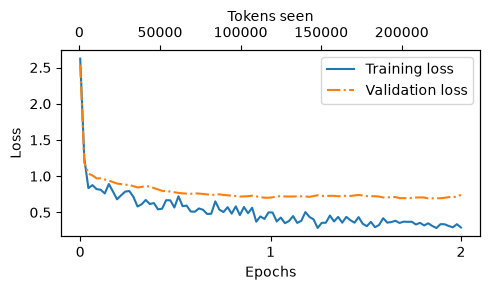

In [29]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

In [33]:
torch.linspace(0, 2, 10)

tensor([0.0000, 0.2222, 0.4444, 0.6667, 0.8889, 1.1111, 1.3333, 1.5556, 1.7778,
        2.0000])

In [34]:
torch.manual_seed(123)

for entry in test_data[:3]:
    input_text = format_input(entry)
    token_ids = generate(
        model = model,
        idx = text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens = 256,
        context_size = BASE_CONFIG['context_length'],
        eos_id = 50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    
    response_text = (
        generated_text[len(input_text):]
        .replace('### Response:', '')
        .strip()
    )
    
    print(input_text)
    print(f'\nCorrect response:\n>> {entry['output']}')
    print(f'\nModel response:\n>> {response_text.strip()}')
    print('---------------------------------')
    

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as an ox.
---------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> A thunderstorm is a type of cloud that typically produces thunder and lightning.
---------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

Correct response:
>> Jane Austen.

Model response:
>> The author of 'Pride and Pr

In [36]:
from tqdm import tqdm 

for i, entry in tqdm(enumerate(test_data), total = len(test_data)):
    input_text = format_input(entry)
    
    token_ids = generate(
        model = model,
        idx = text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens = 256,
        context_size = BASE_CONFIG['context_length'],
        eos_id = 50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    
    response_text = (
        generated_text[len(input_text):]
        .replace('### Response:', '')
        .strip()
    )
    test_data[i]['model_response'] = response_text 
    
with open('instruction-data-with-response.json', 'w') as file:
    json.dump(test_data, file, indent = 4)

100%|██████████| 110/110 [01:28<00:00,  1.24it/s]


In [38]:
print(test_data[0])

{'instruction': 'Rewrite the sentence using a simile.', 'input': 'The car is very fast.', 'output': 'The car is as fast as lightning.', 'model_response': 'The car is as fast as an ox.'}


In [39]:
import re

file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL) }-sft.pth"
torch.save(model.state_dict(), file_name)
print(f'model saved as {file_name}')

model saved as gpt2-medium355M-sft.pth


In [41]:
import psutil

def check_if_running(process_name):
    running = False
    for proc in psutil.process_iter(['name']):
        if process_name in proc.info['name']:
            running = True
            break
    return running

ollama_running = check_if_running('ollama')

if not ollama_running:
    raise RuntimeError(
        'ollama not running. Launch ollama before proceeding.'
    )
print('ollama running:', check_if_running('ollama'))

ollama running: True


In [42]:
def query_model(
    prompt,
    model = 'llama3',
    url = 'http://localhost:11434/api/chat' 
):
    data = {
        'model': model,
        'messages': [{'role': 'user', 'content': prompt}],
        'options': {'seed': 123, 
                    'temperature': 0,
                    'num_ctx': 2048}
    }
    
    payload = json.dumps(data).encode('utf-8')
    request = urllib.request.Request(
        url, 
        data = payload,
        method = 'POST' 
    )
    
    request.add_header('Content-Type', 'application/json')
    
    response_data = '' 
    with urllib.request.urlopen(request) as response:
        while True:
            line = response.readline().decode('utf-8')
            if not line:
                break 
            response_json = json.loads(line)
            response_data += response_json['message']['content']
        
    return response_data

In [43]:
model = 'llama3' 
result = query_model('What do Llamas eat ?', model)
print(result)

Llamas are herbivores, which means they primarily eat plants and plant-based foods. Their diet typically consists of:

1. Grasses: Llamas love to graze on various types of grasses, including tall grasses, short grasses, and even weeds.
2. Hay: Hay, such as alfalfa or timothy hay, is a staple in a llama's diet. It provides essential fiber and nutrients.
3. Grains: Llamas may be fed grains like oats, barley, or corn as a supplement to their diet.
4. Fruits and vegetables: Llamas enjoy fruits and vegetables like apples, carrots, and sweet potatoes as treats or as part of their regular diet.
5. Leaves: Llamas will also eat leaves from trees and shrubs, such as willow, alder, or cedar.
6. Bark: In the winter or when other food sources are scarce, llamas may eat the bark of trees, like aspen or birch.

In the wild, llamas will roam freely and eat whatever is available in their natural habitat. In captivity, their diet is typically formulated to meet their nutritional needs, and they may rece

In [46]:
for entry in test_data[:3]:
    prompt = (
        f'given the input `{format_input(entry)}`'
        f'and correct output `{entry['output']}`'
        f'score the model response `{entry['model_response']}`' 
        f'on a scale from 0 to 100, where 100 is the best score' 
    )  
    
    print('\Dataset response:')
    print('>>', entry['output'])
    print('\nModel response:')
    print('>>', entry ['model_response'])
    print('>>\nScore:')
    print('>>', query_model (prompt))
    print('\n-------------------------')

<>:9: SyntaxWarning: invalid escape sequence '\D'
<>:9: SyntaxWarning: invalid escape sequence '\D'
/var/folders/mq/mh5vptk54wg7f7wwgtgqsm9h0000gn/T/ipykernel_31104/1001397729.py:9: SyntaxWarning: invalid escape sequence '\D'
  print('\Dataset response:')


\Dataset response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as an ox.
>>
Score:
>> I'd score the model response "The car is as fast as an ox." a 20 out of 100.

The original instruction asked to rewrite the sentence using a simile, which is a figure of speech that compares two unlike things using "like" or "as." The input sentence "The car is very fast" is rewritten as "The car is as fast as lightning," which is a good example of a simile because it compares the car's speed to the speed of lightning.

However, the model response "The car is as fast as an ox" is not a good example of a simile because an ox is not typically known for its speed. An ox is a large, slow-moving animal, so comparing the car's speed to an ox's speed is not a meaningful or accurate comparison. Therefore, I would score this response a 20 out of 100.

-------------------------
\Dataset response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model 

In [49]:
def generate_model_scores(json_data, json_key, model = 'llama3'):
    scores = []
    for entry in tqdm(json_data, desc = 'Scoring entries'):
        prompt = (
            f'Given the input `{format_input(entry)}`' 
            f'and correct output `{entry['output']}`' 
            f'score the model response `{entry[json_key]}`' 
            f'on a scale from 0 to 100, where 100 is the best score. ' 
            f'Respone with the integer numer only.' 
        )
        score = query_model(prompt, model)
        try:
            scores.append(int(score))
        except ValueError:
            print(f'Coult not convert score: {score}')
            continue 
    return scores

In [50]:
scores = generate_model_scores(test_data, 'model_response')
print(f'number of scores: {len(scores)} of {len(test_data)}')
print(f"Average score: {sum(scores)/len(scores):.2f}\n")

Scoring entries:  74%|███████▎  | 81/110 [00:06<00:04,  6.78it/s]

Coult not convert score: I'd be happy to help!

### Model Response:
The number IX in Roman numerals is 9.

### Score:
5.5/5 = 110/10 = 11

So, my score is: **11**


Scoring entries:  98%|█████████▊| 108/110 [00:09<00:00,  7.34it/s]

Coult not convert score: The correct output is: The classification of the sentence 'Please open the door.' is imperative.

The score for the model response is: 0


Scoring entries: 100%|██████████| 110/110 [00:10<00:00, 10.63it/s]

Coult not convert score: The model response "She always remembers to call." would score 0 out of 100, as it does not meet the instruction to use a negative adverb.
number of scores: 107 of 110
Average score: 56.24



In [52]:
import os
print([f for f in os.listdir('.') if f.endswith('.pth')])

['review_classifier.pth', 'gpt2-medium355M-sft.pth', 'model_and_optimizer.pth', 'model.pth']


In [53]:
del model
import gc; gc.collect()
torch.mps.empty_cache()